In [87]:
import numpy
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

Loaded SECOM dataset, handled missing values by removing columns with >% nulls,
imputed remaining NaNs using median values, and removed constant sensors.

In [88]:
df=pd.read_csv('Secom.data', sep=r"\s+", header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,1.3424,-0.0045,...,0.0047,203.1720,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,1.4333,-0.0061,...,NaN,NaN,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,NaN,NaN,...,0.0025,43.5231,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,1.4622,-0.0072,...,0.0075,93.4941,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [89]:
df.columns=[f"sensor_{i}" for i in range(1,591)]
df.head()

,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,...,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [90]:
missing_percentage = df.isnull().sum()/len(df)*100

In [91]:
missing_percentage.sort_values(ascending=False)

sensor_293    91.193363
sensor_294    91.193363
sensor_159    91.193363
sensor_158    91.193363
sensor_493    85.577537
                ...    
sensor_524     0.000000
sensor_523     0.000000
sensor_522     0.000000
sensor_521     0.000000
sensor_121     0.000000
Length: 590, dtype: float64

In [92]:
df=df.loc[:,missing_percentage <= 50]
print(df.shape)

(1567, 562)


In [93]:
df=df.fillna(df.median())

In [94]:
df
print(df.isnull().sum())

sensor_1      0
sensor_2      0
sensor_3      0
sensor_4      0
sensor_5      0
             ..
sensor_586    0
sensor_587    0
sensor_588    0
sensor_589    0
sensor_590    0
Length: 562, dtype: int64


In [95]:
constant_col=[]

for col in df.columns :
    if df[col].nunique() ==1:
       constant_col.append(col) 

In [96]:
constant_col

['sensor_6',
 'sensor_14',
 'sensor_43',
 'sensor_50',
 'sensor_53',
 'sensor_70',
 'sensor_98',
 'sensor_142',
 'sensor_150',
 'sensor_179',
 'sensor_180',
 'sensor_187',
 'sensor_190',
 'sensor_191',
 'sensor_192',
 'sensor_193',
 'sensor_194',
 'sensor_195',
 'sensor_227',
 'sensor_230',
 'sensor_231',
 'sensor_232',
 'sensor_233',
 'sensor_234',
 'sensor_235',
 'sensor_236',
 'sensor_237',
 'sensor_238',
 'sensor_241',
 'sensor_242',
 'sensor_243',
 'sensor_244',
 'sensor_257',
 'sensor_258',
 'sensor_259',
 'sensor_260',
 'sensor_261',
 'sensor_262',
 'sensor_263',
 'sensor_264',
 'sensor_265',
 'sensor_266',
 'sensor_267',
 'sensor_277',
 'sensor_285',
 'sensor_314',
 'sensor_315',
 'sensor_316',
 'sensor_323',
 'sensor_326',
 'sensor_327',
 'sensor_328',
 'sensor_329',
 'sensor_330',
 'sensor_331',
 'sensor_365',
 'sensor_370',
 'sensor_371',
 'sensor_372',
 'sensor_373',
 'sensor_374',
 'sensor_375',
 'sensor_376',
 'sensor_379',
 'sensor_380',
 'sensor_381',
 'sensor_382',
 's

In [97]:
df = df.drop(columns=constant_col,errors='ignore')
print(df.shape)
df

(1567, 446)


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,...,sensor_577,sensor_578,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,2899.41,2464.36,2179.7333,3085.3781,1.4843,82.2467,0.1248,1.3424,-0.0045,-0.0057,...,1.4879,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,3052.31,2522.55,2198.5667,1124.6595,0.8763,98.4689,0.1205,1.4333,-0.0061,-0.0093,...,1.0187,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,2978.81,2379.78,2206.3000,1110.4967,0.8236,99.4122,0.1208,1.4616,-0.0013,0.0004,...,1.2237,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,2894.92,2532.01,2177.0333,1183.7287,1.5726,98.7978,0.1213,1.4622,-0.0072,0.0032,...,1.7085,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [98]:
scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)

In [99]:
pc=PCA()
pc_data=pc.fit_transform(scaled_data)

In [100]:
pc_data.shape

(1567, 446)

In [101]:
explained_variance=pc.explained_variance_ratio_
cumulative_variance=explained_variance.cumsum()

In [102]:
n_components=np.argmax(cumulative_variance >=0.95)+1
print(n_components)

162


In [103]:
reduced_data=pc_data[:,:162]
reduced_data.shape
reduced_data


array([[-1.75228518,  2.84484726,  3.76750795, ...,  0.4126494 ,
        -0.21644639, -1.06376775],
       [-2.27506026,  0.72631886,  2.80184975, ...,  0.45822763,
        -0.21877093, -0.13464431],
       [ 0.1053494 ,  0.96561487,  1.24965716, ...,  1.92272668,
         0.30244908,  0.53962065],
       ...,
       [-1.12691117, -1.70340358, -1.65071431, ...,  1.01168332,
         1.23317795, -1.32351936],
       [-1.09045501, -3.20619802, -3.28589437, ..., -1.66274409,
         0.7891195 ,  0.25158231],
       [ 2.10394553, -2.94378767, -2.39473983, ...,  0.38719125,
        -0.46085991,  0.1406007 ]], shape=(1567, 162))

In [104]:
mean_vector=np.mean(reduced_data,axis=0)
mean_vector

array([-1.08825945e-16,  1.45101261e-16,  0.00000000e+00,  0.00000000e+00,
       -7.25506303e-17, -1.81376576e-17, -1.81376576e-17,  3.62753152e-17,
       -2.72064864e-17,  5.44129727e-17,  1.81376576e-17, -7.25506303e-17,
        1.81376576e-17,  7.25506303e-17,  4.53441440e-17,  0.00000000e+00,
       -4.53441440e-17,  1.26963603e-16, -1.36032432e-17, -4.08097296e-17,
       -2.72064864e-17, -1.81376576e-17,  1.81376576e-17,  5.89473871e-17,
       -1.36032432e-17, -2.72064864e-17, -9.06882879e-17,  4.53441440e-17,
        3.62753152e-17,  2.72064864e-17,  3.85425224e-17, -1.81376576e-17,
       -2.72064864e-17,  6.34818015e-17, -4.53441440e-18,  4.08097296e-17,
        4.98785583e-17,  3.62753152e-17,  5.89473871e-17, -3.17409008e-17,
        4.76113512e-17, -9.06882879e-18,  4.08097296e-17,  2.04048648e-17,
        9.06882879e-18,  3.17409008e-17,  2.72064864e-17,  8.16194591e-17,
       -5.44129727e-17, -6.80162159e-18,  7.25506303e-17, -1.81376576e-17,
       -1.13360360e-17, -

In [105]:
cov_matrix=np.cov(reduced_data,rowvar=False)
cov_matrix

array([[ 2.55635884e+01, -1.04494248e-14, -4.10172818e-15, ...,
         1.81492397e-16, -5.08178713e-16,  4.53730993e-17],
       [-1.04494248e-14,  1.72100540e+01,  1.66973006e-15, ...,
        -2.01768501e-16,  2.26865497e-18,  2.67701286e-16],
       [-4.10172818e-15,  1.66973006e-15,  1.33386388e+01, ...,
         3.85671344e-17,  1.97372982e-16,  5.21790642e-17],
       ...,
       [ 1.81492397e-16, -2.01768501e-16,  3.85671344e-17, ...,
         5.67423201e-01, -1.33283479e-16, -3.40298245e-18],
       [-5.08178713e-16,  2.26865497e-18,  1.97372982e-16, ...,
        -1.33283479e-16,  5.60139751e-01,  2.11552076e-16],
       [ 4.53730993e-17,  2.67701286e-16,  5.21790642e-17, ...,
        -3.40298245e-18,  2.11552076e-16,  5.51308110e-01]],
      shape=(162, 162))

In [106]:
inv_cov_matrix=np.linalg.inv(cov_matrix)
inv_cov_matrix

array([[ 3.91181389e-02,  2.37513520e-17,  1.20291114e-17, ...,
        -1.25120806e-17,  3.54893675e-17, -3.21945419e-18],
       [ 2.37513520e-17,  5.81055702e-02, -7.27365202e-18, ...,
         2.06616046e-17, -2.35336789e-19, -2.82145965e-17],
       [ 1.20291114e-17, -7.27365202e-18,  7.49701687e-02, ...,
        -5.09564037e-18, -2.64167750e-17, -7.09562072e-18],
       ...,
       [-1.25120806e-17,  2.06616046e-17, -5.09564037e-18, ...,
         1.76235303e+00,  4.19346322e-16,  1.08782301e-17],
       [ 3.54893675e-17, -2.35336789e-19, -2.64167750e-17, ...,
         4.19346322e-16,  1.78526876e+00, -6.85056697e-16],
       [-3.21945419e-18, -2.82145965e-17, -7.09562072e-18, ...,
         1.08782301e-17, -6.85056697e-16,  1.81386775e+00]],
      shape=(162, 162))

In [107]:
t2_scores=[]
for row  in reduced_data:
    diff=row-mean_vector
    t2=diff.T @ inv_cov_matrix @ diff
    t2_scores.append(t2)


In [108]:
len(t2_scores)

1567

In [109]:
t2_scores=np.array(t2_scores)
t2_scores

array([145.94547883, 147.51635339, 229.96501394, ...,  75.40992939,
       115.62634527,  82.58832452], shape=(1567,))

In [110]:
ucl = np.percentile(t2_scores,95)
print(ucl)

302.74819538428443


In [111]:
out_of_control = np.where(t2_scores > ucl)[0]

print(out_of_control)
print(len(out_of_control))

[   3    4   13   14   15   17   27   38   57  109  113  130  144  243
  258  273  275  300  308  367  375  385  395  403  410  423  455  457
  461  466  488  492  497  529  539  576  634  638  672  689  702  709
  767  856  857  878  923  931  993 1008 1097 1121 1123 1124 1150 1151
 1177 1203 1223 1264 1304 1320 1384 1385 1397 1400 1418 1429 1441 1446
 1456 1458 1459 1461 1469 1489 1519 1536 1560]
79


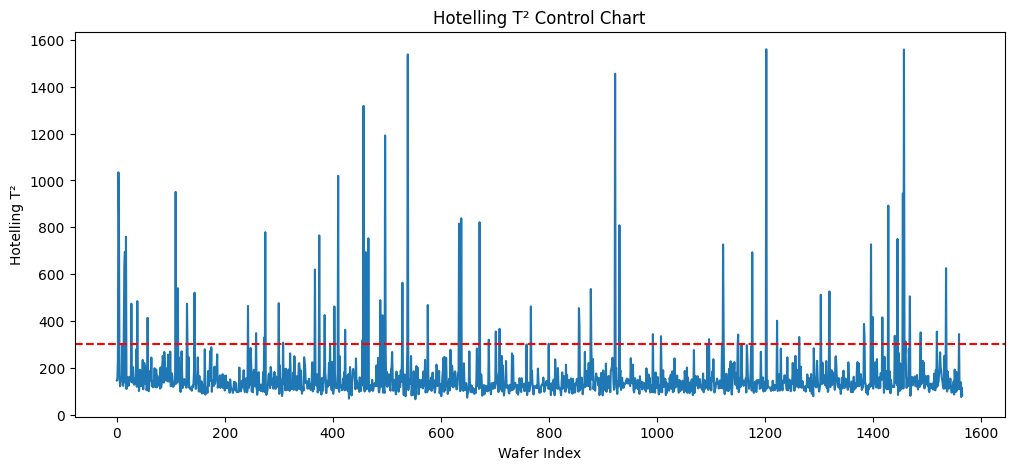

In [112]:
plt.figure(figsize=(12,5))
plt.plot(t2_scores)
plt.axhline(ucl,color='red',linestyle='--')
plt.xlabel("Wafer Index")
plt.ylabel("Hotelling T²")
plt.title("Hotelling T² Control Chart")
plt.show()

In [114]:
summary_table = pd.DataFrame({
    "Metric": [
        "Original sensors",
        "After missing-value cleaning",
        "After constant-column removal",
        "PCs retained",
        "Variance retained",
        "UCL method",
        "Out-of-control wafers",
        "OOC rate"
    ],
    "Value": [
        590,
        562,
        df.shape[1],
        n_components,
        f"{cumulative_variance[n_components-1]*100:.2f}%",
        "95th percentile of T² scores",
        len(out_of_control),
        f"{len(out_of_control)/len(df)*100:.2f}%"
    ]
})

summary_table

,Metric,Value
0,Original sensors,590
1,After missing-value cleaning,562
2,After constant-column removal,446
3,PCs retained,162
4,Variance retained,95.01%
5,UCL method,95th percentile of T² scores
6,Out-of-control wafers,79
7,OOC rate,5.04%


In [115]:
labels = pd.read_csv("secom_labels.data", sep=r"\s+", header=None)
labels.columns = ["label", "timestamp"]

# -1 = pass, 1 = fail
labels["result"] = labels["label"].map({-1: "Pass", 1: "Fail"})

In [117]:
results = labels.copy()
results["T2_score"] = t2_scores
results["OOC"] = results["T2_score"] > ucl
results

,label,timestamp,result,T2_score,OOC
0,-1,19/07/2008 11:55:00,Pass,145.945479,False
1,-1,19/07/2008 12:32:00,Pass,147.516353,False
2,1,19/07/2008 13:17:00,Fail,229.965014,False
3,-1,19/07/2008 14:43:00,Pass,1034.599051,True
4,-1,19/07/2008 15:22:00,Pass,834.151635,True
...,...,...,...,...,...
1562,-1,16/10/2008 15:13:00,Pass,110.913798,False
1563,-1,16/10/2008 20:49:00,Pass,139.609046,False
1564,-1,17/10/2008 05:26:00,Pass,75.409929,False
1565,-1,17/10/2008 06:01:00,Pass,115.626345,False


How many failed wafers were flagged by T²?
How many flagged wafers still passed?
Are failed wafers more likely to have high T²?

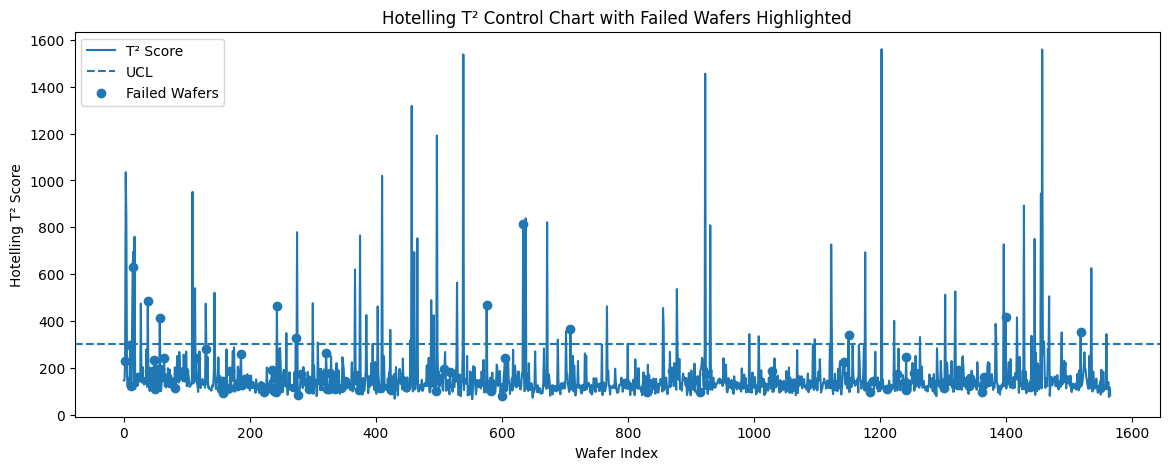

In [118]:
plt.figure(figsize=(14,5))
plt.plot(results["T2_score"], label="T² Score")
plt.axhline(ucl, linestyle="--", label="UCL")

fail_idx = results[results["result"]=="Fail"].index
plt.scatter(fail_idx, results.loc[fail_idx, "T2_score"], label="Failed Wafers")

plt.xlabel("Wafer Index")
plt.ylabel("Hotelling T² Score")
plt.title("Hotelling T² Control Chart with Failed Wafers Highlighted")
plt.legend()
plt.show()

In [119]:
top_ooc = results.sort_values("T2_score", ascending=False).head(10)
top_ooc

,label,timestamp,result,T2_score,OOC
1203,-1,30/09/2008 19:17:00,Pass,1560.125173,True
1458,-1,11/10/2008 07:39:00,Pass,1558.890588,True
539,-1,29/08/2008 15:01:00,Pass,1538.011249,True
923,-1,19/09/2008 20:17:00,Pass,1455.693553,True
457,-1,27/08/2008 22:58:00,Pass,1318.223645,True
497,-1,28/08/2008 21:52:00,Pass,1191.857153,True
3,-1,19/07/2008 14:43:00,Pass,1034.599051,True
410,-1,22/08/2008 09:29:00,Pass,1019.560034,True
109,-1,05/08/2008 04:35:00,Pass,950.880153,True
1456,-1,11/10/2008 06:56:00,Pass,944.128081,True


The highest-risk wafers had T² scores far above the UCL, indicating strong multivariate deviation from normal process behavior.

In [120]:
pc_columns = [f"PC{i+1}" for i in range(n_components)]
reduced_df = pd.DataFrame(reduced_data, columns=pc_columns)

wafer_id = out_of_control[0]

reduced_df.iloc[wafer_id].abs().sort_values(ascending=False).head(10)

PC17    35.435628
PC15    31.087626
PC19    24.245108
PC13    23.366189
PC12    23.343541
PC25    11.789402
PC27    11.713550
PC20    11.203193
PC8     10.307594
PC24     8.640857
Name: 3, dtype: float64

In [122]:
loadings = pd.DataFrame(
    pc.components_[:n_components].T,
    index=df.columns,
    columns=pc_columns
)

top_sensors_pc1 = loadings["PC17"].abs().sort_values(ascending=False).head(10)
top_sensors_pc1

sensor_558    0.194566
sensor_555    0.193857
sensor_552    0.193485
sensor_557    0.181769
sensor_551    0.178070
sensor_554    0.171598
sensor_131    0.169776
sensor_123    0.163513
sensor_128    0.155274
sensor_313    0.141379
Name: PC17, dtype: float64

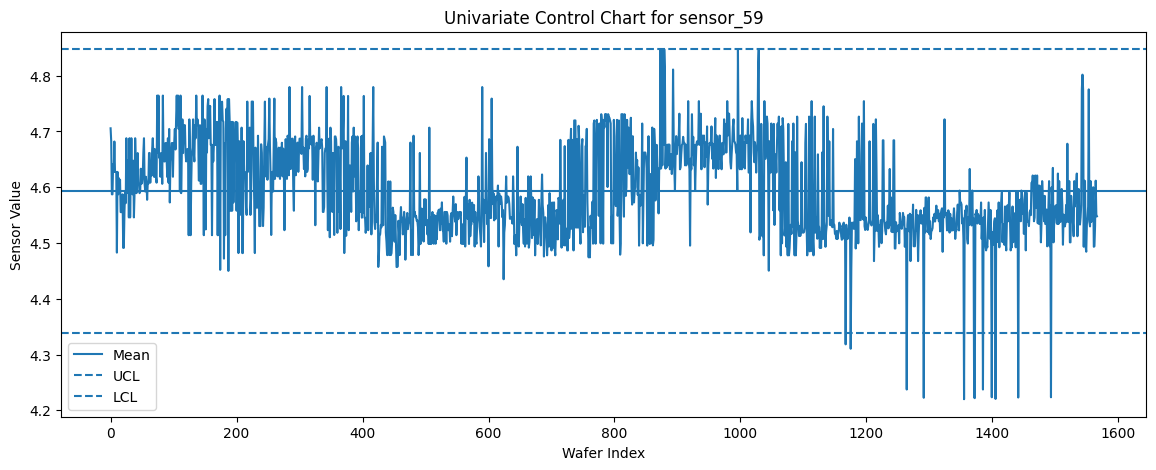

In [ ]:
sensor = "sensor_558"

mean = df[sensor].mean()
std = df[sensor].std()
ucl_sensor = mean + 3*std
lcl_sensor = mean - 3*std

plt.figure(figsize=(14,5))
plt.plot(df[sensor])
plt.axhline(mean, linestyle="-", label="Mean")
plt.axhline(ucl_sensor, linestyle="--", label="UCL")
plt.axhline(lcl_sensor, linestyle="--", label="LCL")
plt.title(f"Univariate Control Chart for {sensor}")
plt.xlabel("Wafer Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.show()

univariate control charts for top contributing sensor_558 in PC17 for wafer 1.